In [19]:
from aeon.io.api import load
from aeon.schema.streams import Device
from aeon.schema import core as stream
from aeon.schema.streams import Stream, StreamGroup
import aeon.io.reader as _reader
from dotmap import DotMap
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# We have some experiment specific data streams (not included in ucl-open or aeon) so we need to first define their readers
class Texture(Stream):
    """Texture change log."""
    def __init__(self, pattern):
        super().__init__(_reader.Csv(f"{pattern}_*", ["texture"]))

class Arduino(Stream):
    def __init__(self, pattern):
        super().__init__(_reader.Csv(f"{pattern}_*", ["encoder_count", "lick_count_left", "lick_count_right", "last_sync_pulse_time", "photodiode_value", "current_ms"]))

class ArduinoPhotodiode(Stream):
    def __init__(self, pattern):
        super().__init__(_reader.Csv(f"{pattern}_*", ["photodiode_value", "sync_value"]))

In [3]:
# Define the data components of the experiment
# Experiment is defined as a set of devices with a name (corresponding to the data stream folder) and a stream reader
exp = DotMap(
    [
        Device("Texture", Texture),
        Device("Arduino", Arduino),
        Device("ArduinoPhotodiode", ArduinoPhotodiode),
        Device("VideoData", stream.Video),
    ]
)

# We also have a data directory where we look for the data
data_dir = Path("C:/Users/neurogears/source/repos/ucl-open/hf-visual/temp_data/ses-20251217_1_date-2025-12-17T17-27-21/")


**/**/Arduino_*.csv
**/**/Texture_*.csv
                          texture
time                             
1904-01-01 00:00:12.286    blank1
1904-01-01 00:00:13.038    SN_4_2
1904-01-01 00:00:13.290    blank1
1904-01-01 00:00:14.052    SN_4_1
1904-01-01 00:00:14.304    blank1
...                           ...
1904-01-01 00:15:01.098    SN_4_2
1904-01-01 00:15:01.348    blank1
1904-01-01 00:15:02.112    SN_4_3
1904-01-01 00:15:02.362    blank1
1904-01-01 00:15:03.115  SImg_4_5

[1762 rows x 1 columns]


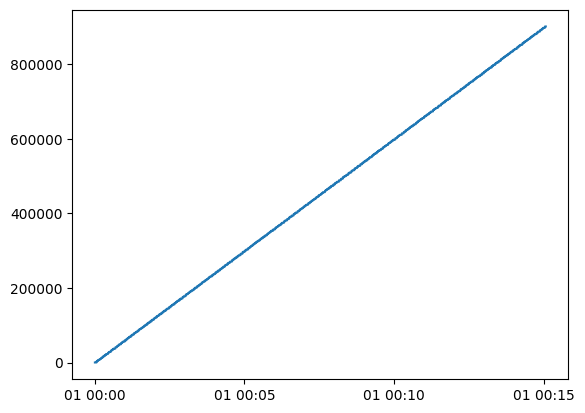

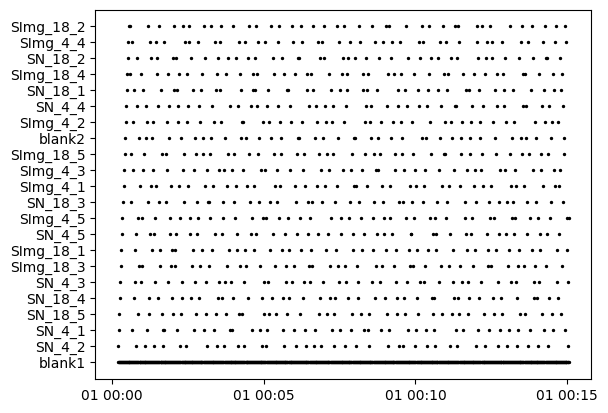

In [4]:
# We can now load device data with a single line
arduino_data = load(data_dir, exp.Arduino)
texture_data = load(data_dir, exp.Texture)
print(texture_data)

plt.figure()
plt.plot(arduino_data['last_sync_pulse_time'])

plt.figure()
plt.scatter(texture_data.index, texture_data['texture'], c='k', s=2)

**/**/ArduinoPhotodiode_*.csv
                        texture
time                           
1904-01-01 00:00:14.052  SN_4_1
time
1904-01-01 00:00:14.082    1.0
Name: photodiode_binarised, dtype: float64
                          texture
time                             
1904-01-01 00:00:13.078    SN_4_2
1904-01-01 00:00:13.330    blank1
1904-01-01 00:00:14.082    SN_4_1
1904-01-01 00:00:14.334    blank1
1904-01-01 00:00:15.096   SN_18_5
...                           ...
1904-01-01 00:15:01.138    SN_4_2
1904-01-01 00:15:01.388    blank1
1904-01-01 00:15:02.152    SN_4_3
1904-01-01 00:15:02.402    blank1
1904-01-01 00:15:03.156  SImg_4_5

[1761 rows x 1 columns]


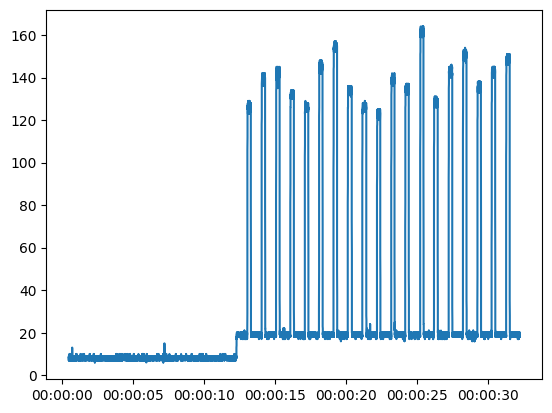

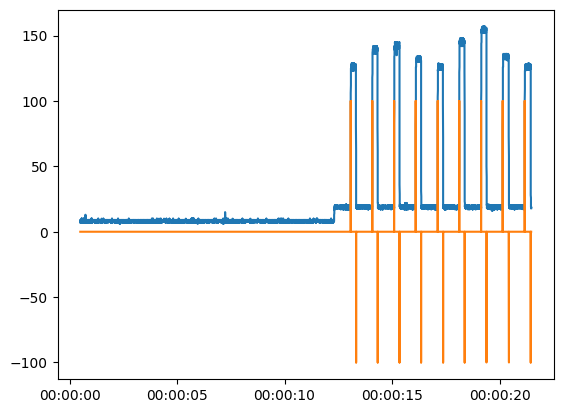

In [13]:
# Texture timestamps were assigned in software. 
# We now find the true onset times from the photodiode data.
arduino_photodiode_data = load(data_dir, exp.ArduinoPhotodiode)

plt.figure()
plt.plot(arduino_photodiode_data['photodiode_value'][0:30000])

# binarise photodiode trace
threshold = lambda x: x>60.0
arduino_photodiode_data['photodiode_binarised'] = arduino_photodiode_data['photodiode_value'].apply(threshold).astype(int).diff()

plt.figure()
plt.plot(arduino_photodiode_data['photodiode_value'][0:20000])
plt.plot(arduino_photodiode_data['photodiode_binarised'][0:20000] * 100.0)

# extract onset and offset times
onsets = arduino_photodiode_data['photodiode_binarised'][arduino_photodiode_data['photodiode_binarised'] == 1]
offsets = arduino_photodiode_data['photodiode_binarised'][arduino_photodiode_data['photodiode_binarised'] == -1]

# we don't get an offset for the initial blank, so we'll reindex texture data to exclude first value
texture_stimuli = texture_data[1::]
assert((len(onsets)+len(offsets)) == len(texture_stimuli))

# we can see the issue with software timestamping clearly if we compare the bonsai assigned time vs. the photodiode 'true' time
print(texture_stimuli.iloc[[2]])
print(onsets.iloc[[1]])
# in this example, the software timestamp is ~50ms later than the photodiode recorded onset time. Pretty close, but since we assign the latest timestamp at runtime in bonsai, there will be some delay between the stimulus onset and attaching the timestamp.

# let's apply the 'true' timestamps to the texture sequence
texture_stimuli.index = pd.concat([onsets, offsets], axis=0).sort_index().index
print(texture_stimuli)

In [18]:
# Now that we have texture data with 'true' timestamps, we can e.g. extract video frames around a texture stimulus onset
# We have the same issue as with the texture data, we assign timestamps in bonsai, but we also have a 'true' trigger time from the arduino

print(arduino_data)

                         encoder_count  lick_count_left  lick_count_right  \
time                                                                        
1904-01-01 00:00:00.499            887                0                 0   
1904-01-01 00:00:00.509            910                0                 0   
1904-01-01 00:00:00.519            933                0                 0   
1904-01-01 00:00:00.529            959                0                 0   
1904-01-01 00:00:00.539            985                0                 0   
...                                ...              ...               ...   
1904-01-01 00:15:03.256        2064692                0                 0   
1904-01-01 00:15:03.266        2064706                0                 0   
1904-01-01 00:15:03.276        2064719                0                 0   
1904-01-01 00:15:03.286        2064733                0                 0   
1904-01-01 00:15:03.296        2064745                0                 0   